# Projekt 6

## Filip Nocoń
---

### Inicjalizacja potrzebnych bibliotek

In [1]:
# Tutaj należy zaimport pandas as pdimportować potrzebne biblioteki.:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import numpy as np
%matplotlib inline

----
### 1. Wczytanie plików z danymi

In [2]:
df = pd.read_csv("data_7r.csv")
df.head()

df_clean = df.drop(columns=['cluster'])

---
### 2. Wyznaczenie modeli k-means oraz sumy kwadratów odległości próbek do najbliższego centrum klastra (k=2...16)

#### 2.1 init='k-means++'

In [3]:
k_range = range(2, 17)
k_interia = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(df_clean)
    k_interia.append(kmeans.inertia_)

##### Wykres sum kwadratów odległości próbek od centrów w zależności od postulowanej liczby skupień (init='k-means++')

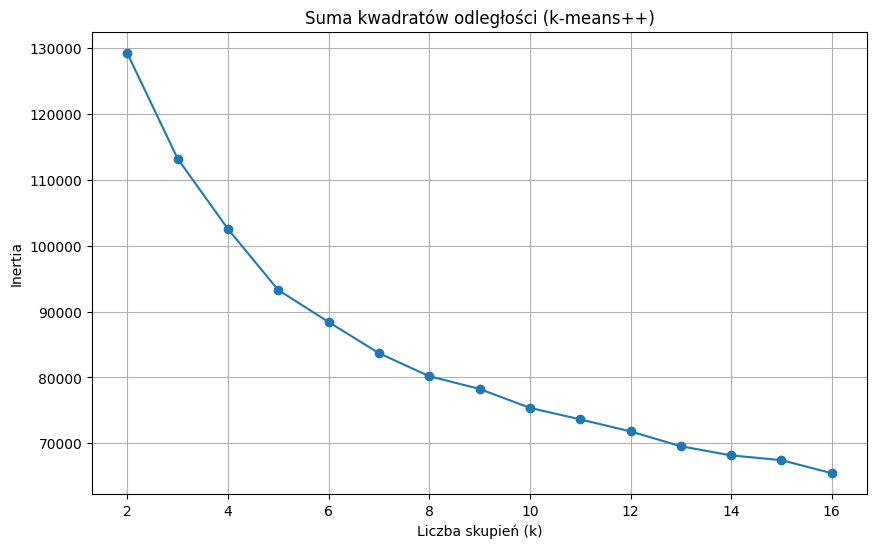

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, k_interia, marker='o')
plt.title('Suma kwadratów odległości (k-means++)')
plt.xlabel('Liczba skupień (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

#### 2.2 init='random'

In [5]:
k_random = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='random', n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(df_clean)
    k_random.append(kmeans.inertia_)

##### Wykres sum kwadratów odległości próbek od centrów w zależności od postulowanej liczby skupień (init='random')

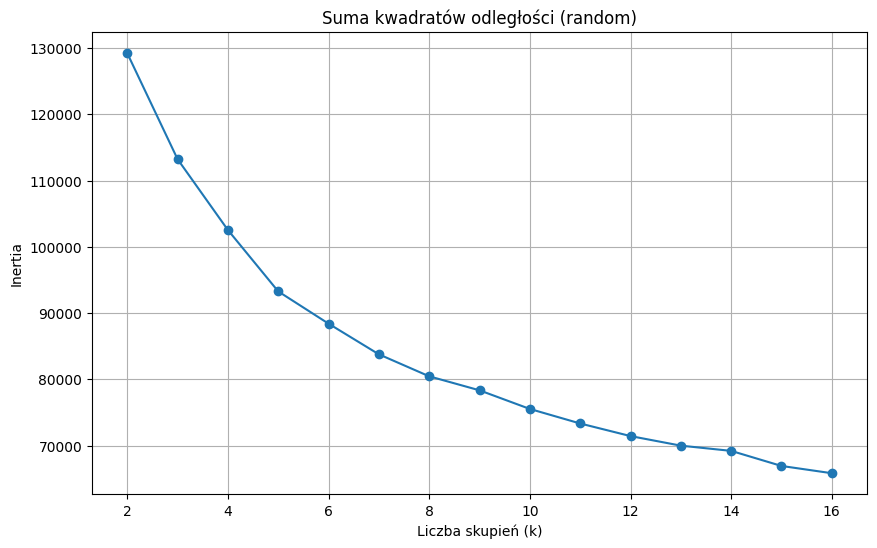

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, k_random, marker='o')
plt.title('Suma kwadratów odległości (random)')
plt.xlabel('Liczba skupień (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

---
### 3. Wyznaczenie średnich wartości współczynnika sylwetki (silhouette) k=2...16

#### 3.1 init='k-means++'

In [7]:
k_silhouette = []
k_silhouette_random = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(df_clean)
  
    score = silhouette_score(df_clean, cluster_labels)
    k_silhouette.append(score)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='random', n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(df_clean)
  
    score = silhouette_score(df_clean, cluster_labels)
    k_silhouette_random.append(score)

##### Wykres średnich wartości współczynnika silhouette w zależności od postulowanej liczby skupień (init='k-means++')

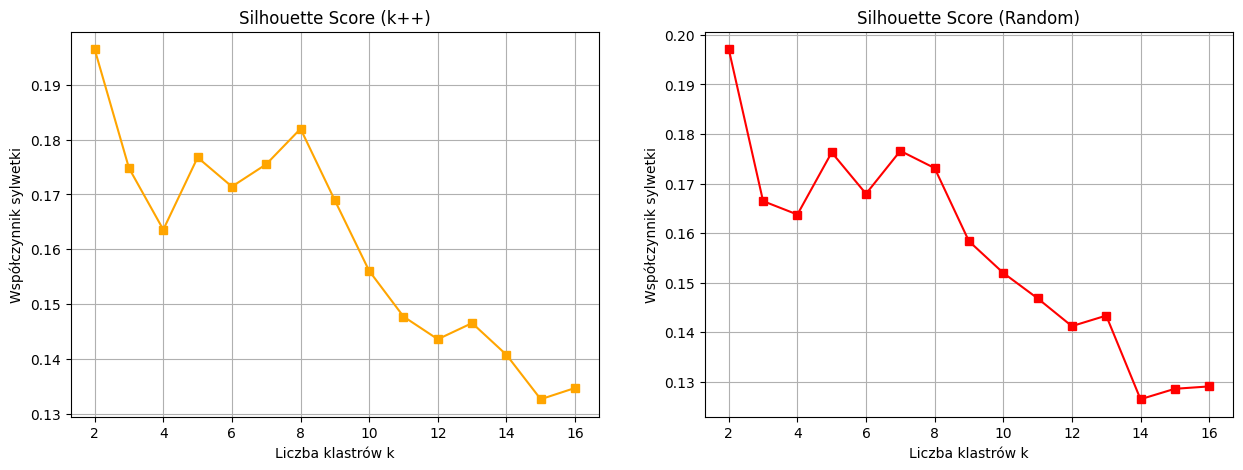

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(k_range, k_silhouette, marker='s', color='orange')
ax[0].set_title('Silhouette Score (k++)')
ax[0].set_xlabel('Liczba klastrów k')
ax[0].set_ylabel('Współczynnik sylwetki')
ax[0].grid(True)

ax[1].plot(k_range, k_silhouette_random, marker='s', color='red')
ax[1].set_title('Silhouette Score (Random)')
ax[1].set_xlabel('Liczba klastrów k')
ax[1].set_ylabel('Współczynnik sylwetki')
ax[1].grid(True)

plt.show()

#### Wnioski:


### Jaką liczbę skupień należy przyjąć na podstawie algorytmu k-means?
### Wydaje mi się, że dla 8 bo jest to maksimum.

---
### 4. Dla chętnych – analiza skupień za pomoca algorytmu DBSCAN

###

In [9]:
# Eksportowanie bieżacego notatnika do pdf.

%run ../data/notebook_export
export_notebook_to_pdf("Projekt6_Nocoń_Filip.ipynb")

Export 'Projekt6_Nocoń_Filip.ipynb': OK.


<Figure size 640x480 with 0 Axes>